In [1]:
!pip install tensorflow
!pip install keras

In [2]:
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random


<p style="font-family: 'Pacifico', cursive, sans-serif; font-size: 40px; color: purple; text-align: center;">
Data Loading and Preprocessing
</p>

In [3]:

# Local copy of https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
dataset_path = 'Rice_Image_Dataset'

images = []
labels = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path):
        continue
    
    for img_name in os.listdir(cls_path):
        images.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': images,
    'label': labels
})

df.head()


,image,label
0,Rice_Image_Dataset\Arborio\Arborio (1).jpg,Arborio
1,Rice_Image_Dataset\Arborio\Arborio (10).jpg,Arborio
2,Rice_Image_Dataset\Arborio\Arborio (100).jpg,Arborio
3,Rice_Image_Dataset\Arborio\Arborio (1000).jpg,Arborio
4,Rice_Image_Dataset\Arborio\Arborio (10000).jpg,Arborio


In [4]:
df

,image,label
0,Rice_Image_Dataset\Arborio\Arborio (1).jpg,Arborio
1,Rice_Image_Dataset\Arborio\Arborio (10).jpg,Arborio
2,Rice_Image_Dataset\Arborio\Arborio (100).jpg,Arborio
3,Rice_Image_Dataset\Arborio\Arborio (1000).jpg,Arborio
4,Rice_Image_Dataset\Arborio\Arborio (10000).jpg,Arborio
...,...,...
74995,Rice_Image_Dataset\Karacadag\Karacadag (9995).jpg,Karacadag
74996,Rice_Image_Dataset\Karacadag\Karacadag (9996).jpg,Karacadag
74997,Rice_Image_Dataset\Karacadag\Karacadag (9997).jpg,Karacadag
74998,Rice_Image_Dataset\Karacadag\Karacadag (9998).jpg,Karacadag


In [5]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.3, random_state=42)

In [6]:
df.describe()

,image,label
count,75000,75000
unique,75000,5
top,Rice_Image_Dataset\Arborio\Arborio (1).jpg,Arborio
freq,1,15000


In [7]:
df['label'].value_counts()

label
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   75000 non-null  object
 1   label   75000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [9]:
print(df.isnull().sum())

image    0
label    0
dtype: int64


In [10]:
train_df['label'].value_counts()

label
Karacadag    9499
Basmati      9447
Arborio      9443
Jasmine      9441
Ipsala       9420
Name: count, dtype: int64

In [11]:
print(train_df.shape[0])


47250


In [12]:
train_df.describe()


,image,label
count,47250,47250
unique,47250,5
top,Rice_Image_Dataset\Ipsala\Ipsala (8066).jpg,Karacadag
freq,1,9499


In [13]:
test_df['label'].value_counts()

label
Basmati      1537
Arborio      1522
Ipsala       1522
Karacadag    1463
Jasmine      1456
Name: count, dtype: int64

In [14]:
val_df['label'].value_counts()

label
Jasmine      4103
Ipsala       4058
Karacadag    4038
Arborio      4035
Basmati      4016
Name: count, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21168\639801657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


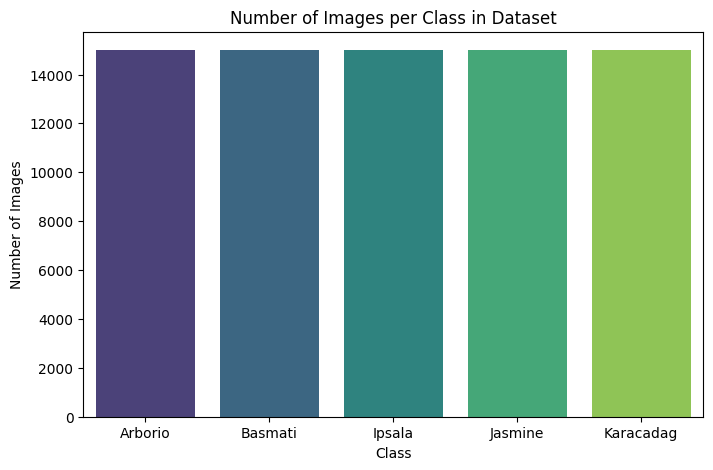

In [15]:

class_counts = df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21168\3905028514.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


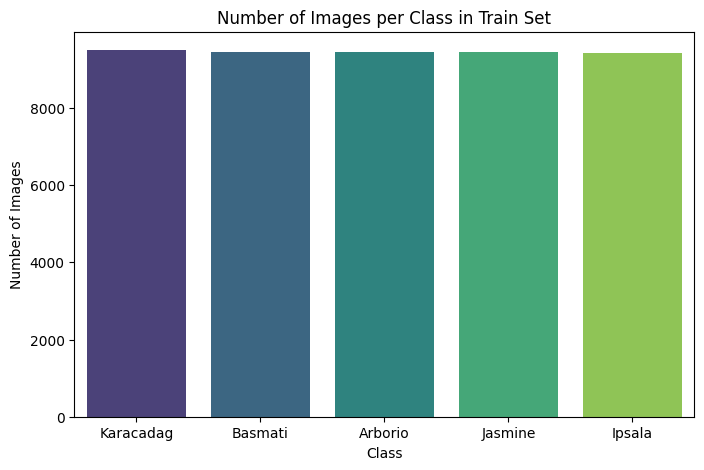

In [16]:

class_counts = train_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Train Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21168\2509845545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


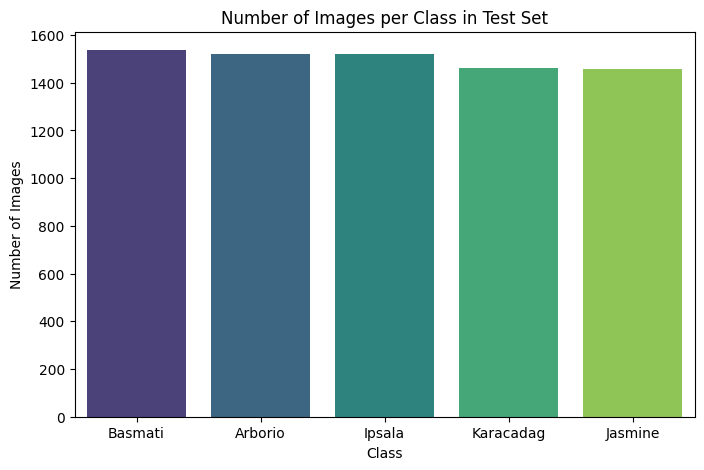

In [17]:

class_counts = test_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Test Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21168\25933517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


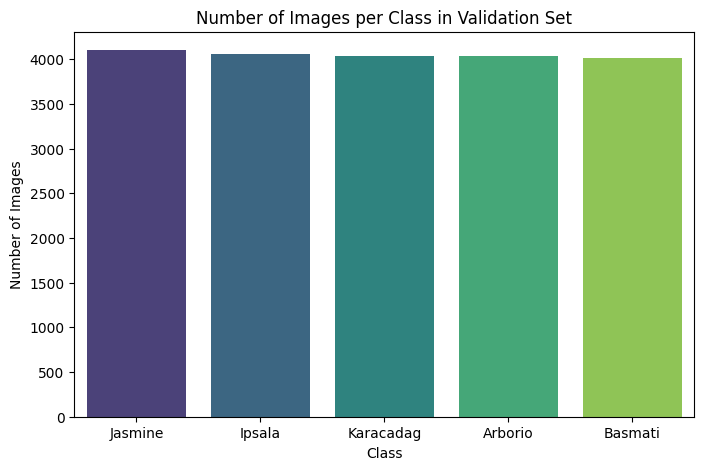

In [18]:

class_counts = val_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Validation Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


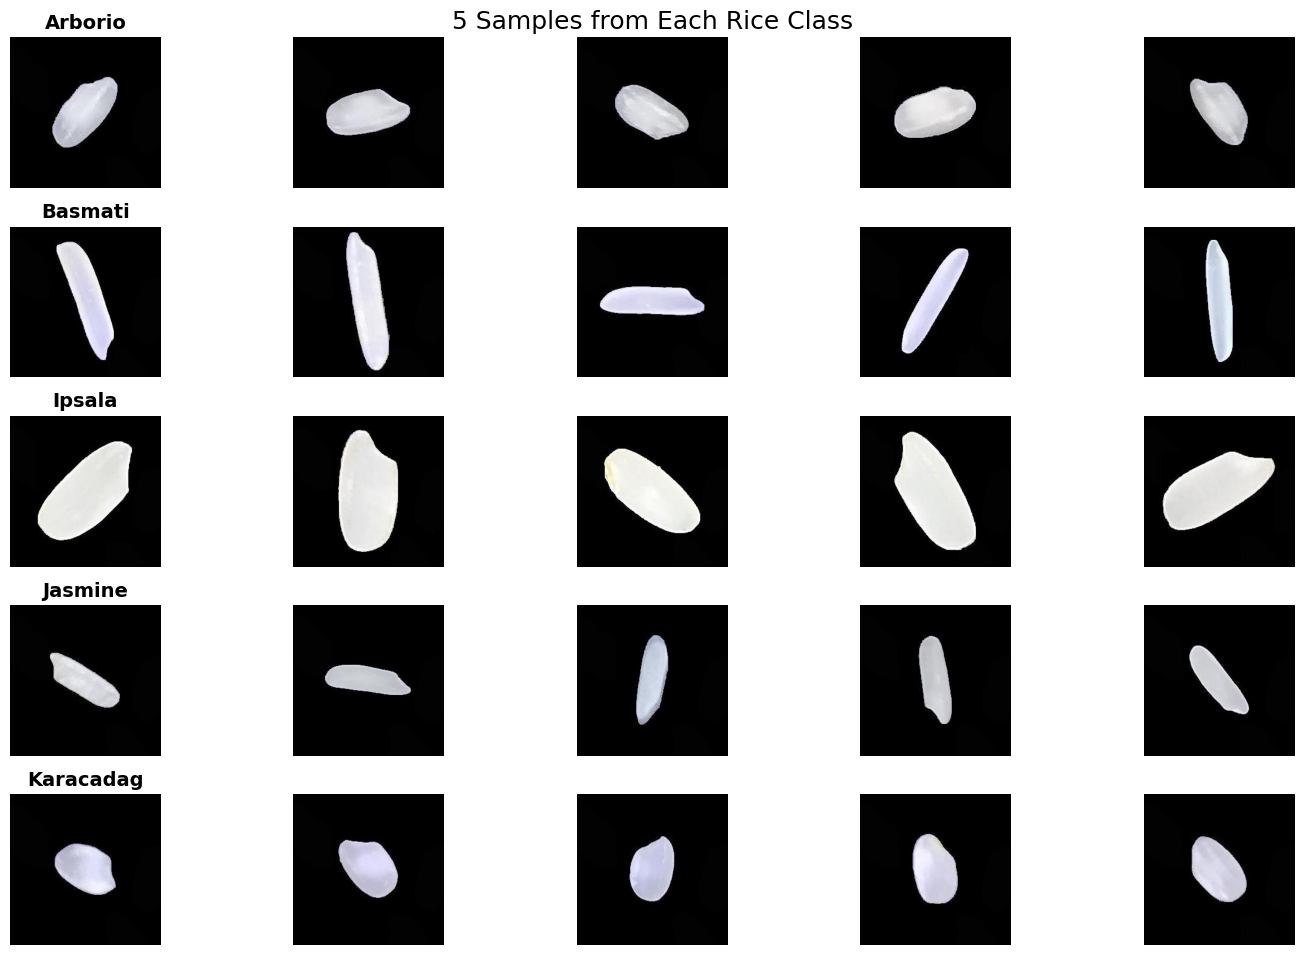

In [19]:
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 10))
plot_idx = 1

for cls in df['label'].unique():
    class_df = df[df['label'] == cls]
    samples = class_df.sample(n=5, random_state=42)
    
    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.image)                 
        plt.subplot(5, 5, plot_idx)
        plt.imshow(img)
        if i == 0:
            plt.title(cls, fontsize=14, fontweight='bold')
        plt.axis('off')
        plot_idx += 1

plt.suptitle('5 Samples from Each Rice Class', fontsize=18, y=0.95)
plt.tight_layout()
plt.show()                                          

In [20]:
classes = sorted(train_df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

In [21]:
def df_to_dataset(dataframe, class_to_idx,
                  num_classes=5, img_size=(128,128),
                  batch_size=32, shuffle=True):

    paths  = dataframe["image"].values
    labels = dataframe["label"].map(class_to_idx).values

    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))

    def process_path(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0 
        return img, label

    # Shuffle the (path, label) pairs before decoding: still a full random shuffle
    # every epoch, but the buffer holds file names instead of ~9 GB of decoded images.
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))

    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [22]:
Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 40px; color: purple; text-align: center;">
Building a CNN with a simple architecture
</p>

In [23]:
CNN = tf.keras.models.Sequential()

#cov 1:
CNN.add(tf.keras.layers.Conv2D(filters=32 , kernel_size=3 , activation='relu' , input_shape=[128,128,3]))
#pooling 1 :
CNN.add(tf.keras.layers.MaxPool2D(pool_size=2 , strides=2))
#Flatting 1 :
CNN.add(tf.keras.layers.Flatten())
#Full Connection 1 :
CNN.add(tf.keras.layers.Dense(units=256 , activation='relu'))
#Output layer :
CNN.add(tf.keras.layers.Dense(units=5 , activation='sigmoid'))


In [24]:
#Compile & Fit :
CNN.compile(optimizer='adam',loss='categorical_crossentropy', metrics=["accuracy"])
m1=CNN.fit(x=Train , validation_data=Validation , epochs=10)

Epoch 1/10
1477/1477 [==============================] - 46s 31ms/step - loss: 0.1079 - accuracy: 0.9652 - val_loss: 0.0726 - val_accuracy: 0.9766
Epoch 2/10
1477/1477 [==============================] - 37s 25ms/step - loss: 0.0415 - accuracy: 0.9855 - val_loss: 0.0507 - val_accuracy: 0.9831
Epoch 3/10
1477/1477 [==============================] - 36s 24ms/step - loss: 0.0269 - accuracy: 0.9912 - val_loss: 0.0772 - val_accuracy: 0.9763
Epoch 4/10
1477/1477 [==============================] - 35s 24ms/step - loss: 0.0215 - accuracy: 0.9927 - val_loss: 0.0436 - val_accuracy: 0.9870
Epoch 5/10
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0188 - accuracy: 0.9934 - val_loss: 0.0539 - val_accuracy: 0.9848
Epoch 6/10
1477/1477 [==============================] - 36s 24ms/step - loss: 0.0141 - accuracy: 0.9950 - val_loss: 0.0521 - val_accuracy: 0.9877
Epoch 7/10
1477/1477 [==============================] - 35s 24ms/step - loss: 0.0111 - accuracy: 0.9960 - val_loss: 0.0571 -

In [25]:
import pickle

# Paths for saving
os.makedirs('working', exist_ok=True)
#model_path = 'working/simple_cnn_model2.keras'
history_path = 'working/simple_cnn_model1_history.pkl'

# Save trained model
#CNN.save(model_path)
#print("Model saved successfully at:", model_path)

# Save training history from m1
with open(history_path, 'wb') as f:
    pickle.dump(m1.history, f)
print("Training history saved successfully at:", history_path)


Training history saved successfully at: working/simple_cnn_model1_history.pkl


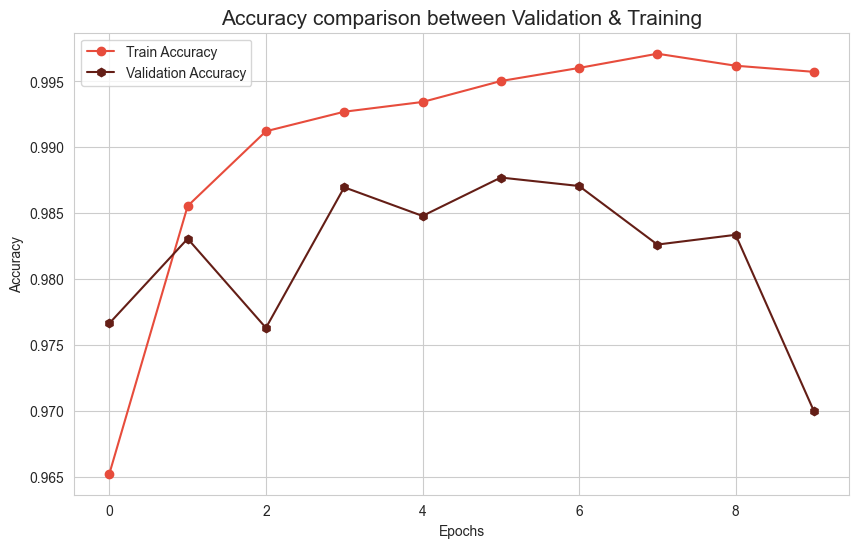

In [26]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m1.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m1.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Let's build a deeper and stronger CNN model
</p>

<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 30px; color: blue; text-align: center;">
Increasing the number of validation samples
</p>

In [27]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.45, random_state=42)

In [28]:
Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


In [29]:
CNN1 = tf.keras.models.Sequential()

#cov 1:
CNN1.add(tf.keras.layers.Conv2D(filters=32 , kernel_size=3 , activation='relu' , input_shape=[128,128,3]))
#pooling 1 :
CNN1.add(tf.keras.layers.MaxPool2D(pool_size=2 , strides=2))
#Flatting 1 :
CNN1.add(tf.keras.layers.Flatten())
#Full Connection 1 :
CNN1.add(tf.keras.layers.Dense(units=256 , activation='relu'))
#Output layer :
CNN1.add(tf.keras.layers.Dense(units=5 , activation='softmax'))


In [30]:
#Compile & Fit :
CNN1.compile(optimizer='adam',loss='categorical_crossentropy', metrics=["accuracy"])
m2=CNN1.fit(x=Train , validation_data=Validation , epochs=10)

Epoch 1/10
1161/1161 [==============================] - 33s 28ms/step - loss: 0.1307 - accuracy: 0.9550 - val_loss: 0.0736 - val_accuracy: 0.9756
Epoch 2/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0542 - accuracy: 0.9816 - val_loss: 0.1142 - val_accuracy: 0.9634
Epoch 3/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0370 - accuracy: 0.9874 - val_loss: 0.1509 - val_accuracy: 0.9467
Epoch 4/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0253 - accuracy: 0.9912 - val_loss: 0.0814 - val_accuracy: 0.9766
Epoch 5/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0219 - accuracy: 0.9925 - val_loss: 0.0949 - val_accuracy: 0.9725
Epoch 6/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0187 - accuracy: 0.9936 - val_loss: 0.0868 - val_accuracy: 0.9789
Epoch 7/10
1161/1161 [==============================] - 32s 28ms/step - loss: 0.0126 - accuracy: 0.9957 - val_loss: 0.1031 -

In [31]:
import pickle

# Paths for saving
os.makedirs('working', exist_ok=True)
#model_path = 'working/simple_cnn_model2.keras'
history_path = 'working/simple_cnn_model2_history.pkl'

# Save trained model
#CNN.save(model_path)
#print("Model saved successfully at:", model_path)

# Save training history from m2
with open(history_path, 'wb') as f:
    pickle.dump(m2.history, f)
print("Training history saved successfully at:", history_path)


Training history saved successfully at: working/simple_cnn_model2_history.pkl


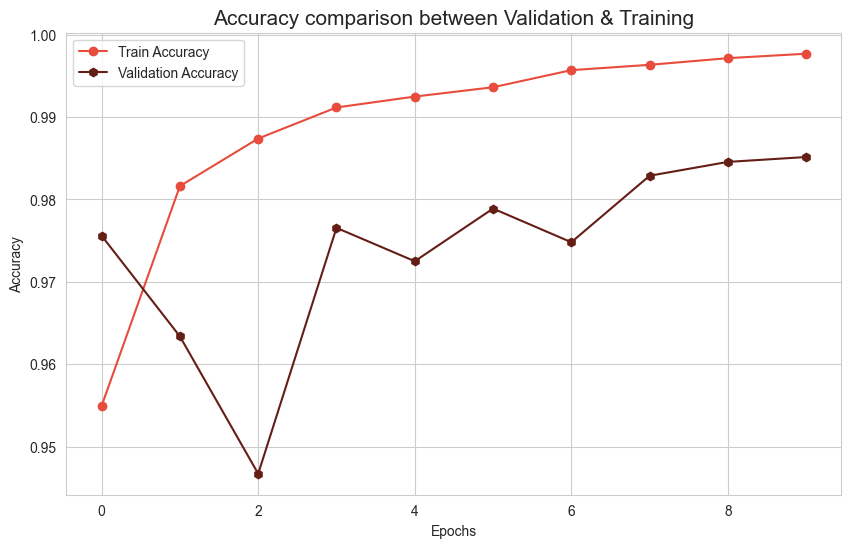

In [32]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m2.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m2.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Model is Overfitting!
</p>

In [33]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.3, random_state=42)

Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Returned validation & train split to original ratio – but making the network deeper and stronger<br></p>

<p style="font-family: 'Pacifico', cursive, sans-serif; font-size: 42px; color: #9b59b6; text-align: center;">
CNN3 Model Architecture
</p>

<hr style="border: 2px solid purple; border-radius: 5px;">

<p style="font-family: 'Georgia', serif; font-size: 18px; color: #2c3e50; text-align: center; line-height: 1.8;">
<strong>A deep Convolutional Neural Network designed to reduce overfitting and improve<br>generalization on image classification tasks.</strong>
</p>

<p style="font-family: 'Georgia', serif; font-size: 17px; color: #34495e; text-align: center; line-height: 2;">
<strong>Techniques used to prevent overfitting:</strong><br>
• Multiple convolutional blocks with Batch Normalization<br>
• Progressive Dropout rates (0.25 → 0.30 → 0.40 → 0.50)<br>
• Lower learning rate for stable training (Adam lr=0.0003)<br>
• Deeper feature extraction using stacked Conv2D layers<br><br>
<strong>This architecture aims to achieve high accuracy (96%–99%) on both training<br>and validation datasets with improved stability and reduced variance.</strong>
</p>

In [34]:
from tensorflow.keras import layers, models, optimizers

CNN3 = models.Sequential()

# Block 1
CNN3.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN3.add(layers.BatchNormalization())
CNN3.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
CNN3.add(layers.BatchNormalization())
CNN3.add(layers.MaxPool2D(2,2))
CNN3.add(layers.Dropout(0.25))

# Block 2
CNN3.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
CNN3.add(layers.BatchNormalization())
CNN3.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
CNN3.add(layers.BatchNormalization())
CNN3.add(layers.MaxPool2D(2,2))
CNN3.add(layers.Dropout(0.30))

# Fully Connected
CNN3.add(layers.Flatten())
CNN3.add(layers.Dense(256, activation='relu'))
CNN3.add(layers.BatchNormalization())
CNN3.add(layers.Dropout(0.50))

# Output Layer
CNN3.add(layers.Dense(5, activation='softmax'))

# Compile
opt = optimizers.Adam(learning_rate=0.0003)
CNN3.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [35]:
m4=CNN3.fit(x=Train , validation_data=Validation , epochs=10)


Epoch 1/10
1477/1477 [==============================] - 128s 85ms/step - loss: 0.0835 - accuracy: 0.9748 - val_loss: 2.3976 - val_accuracy: 0.4982
Epoch 2/10
1477/1477 [==============================] - 123s 83ms/step - loss: 0.0354 - accuracy: 0.9885 - val_loss: 0.0442 - val_accuracy: 0.9873
Epoch 3/10
1477/1477 [==============================] - 126s 85ms/step - loss: 0.0314 - accuracy: 0.9905 - val_loss: 0.1901 - val_accuracy: 0.9367
Epoch 4/10
1477/1477 [==============================] - 122s 82ms/step - loss: 0.0257 - accuracy: 0.9917 - val_loss: 0.0416 - val_accuracy: 0.9855
Epoch 5/10
1477/1477 [==============================] - 117s 79ms/step - loss: 0.0278 - accuracy: 0.9911 - val_loss: 0.0486 - val_accuracy: 0.9830
Epoch 6/10
1477/1477 [==============================] - 117s 79ms/step - loss: 0.0221 - accuracy: 0.9925 - val_loss: 0.0918 - val_accuracy: 0.9836
Epoch 7/10
1477/1477 [==============================] - 117s 79ms/step - loss: 0.0190 - accuracy: 0.9937 - val_loss: 0

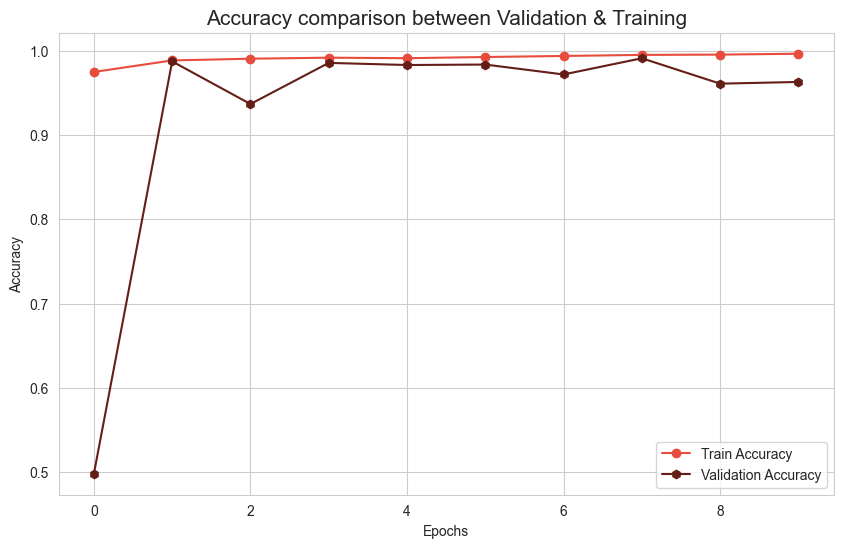

In [36]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m4.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m4.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Previous model was too heavy → Making it lighter and more stable
</p>

<p style="font-family: 'Georgia', serif; font-size: 22px; color: #2c3e50; text-align: center; line-height: 2.2;">
Changes applied:<br>
• Kept only <strong>one convolutional block</strong><br>
• Added <strong>two consecutive MaxPooling layers</strong> right after it<br>
Goal → Drastically reduce parameter count, stabilize loss fluctuations, and prevent overfitting<br>
Result → Much lighter model with smoother training and better generalization
</p>

In [37]:
from tensorflow.keras import layers, models, optimizers

CNN4 = models.Sequential()

# Block 1
CNN4.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN4.add(layers.BatchNormalization())
CNN4.add(layers.MaxPool2D(2,2))
CNN4.add(layers.MaxPool2D(2,2))
CNN4.add(layers.Dropout(0.3))

CNN4.add(layers.Flatten())
CNN4.add(layers.Dense(256, activation='relu'))
CNN4.add(layers.BatchNormalization())
CNN4.add(layers.Dropout(0.5))
CNN4.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN4.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [38]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)


In [39]:


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    return img, label

Train_aug = Train.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


m5 = CNN4.fit(
    Train_aug,
    epochs=17,
    validation_data=Validation,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/17
1477/1477 [==============================] - 43s 29ms/step - loss: 0.1199 - accuracy: 0.9613 - val_loss: 0.0671 - val_accuracy: 0.9768 - lr: 0.0010
Epoch 2/17
1477/1477 [==============================] - 43s 29ms/step - loss: 0.0563 - accuracy: 0.9817 - val_loss: 0.8622 - val_accuracy: 0.7512 - lr: 0.0010
Epoch 3/17
1477/1477 [==============================] - 44s 30ms/step - loss: 0.0498 - accuracy: 0.9841 - val_loss: 0.1146 - val_accuracy: 0.9649 - lr: 0.0010
Epoch 4/17
1477/1477 [==============================] - 43s 29ms/step - loss: 0.0440 - accuracy: 0.9860 - val_loss: 0.0403 - val_accuracy: 0.9899 - lr: 0.0010
Epoch 5/17
1477/1477 [==============================] - 42s 29ms/step - loss: 0.0440 - accuracy: 0.9859 - val_loss: 0.1810 - val_accuracy: 0.9457 - lr: 0.0010
Epoch 6/17
1477/1477 [==============================] - 44s 30ms/step - loss: 0.0563 - accuracy: 0.9817 - val_loss: 0.0617 - val_accuracy: 0.9779 - lr: 0.0010
Epoch 7/17
1477/1477 [========================

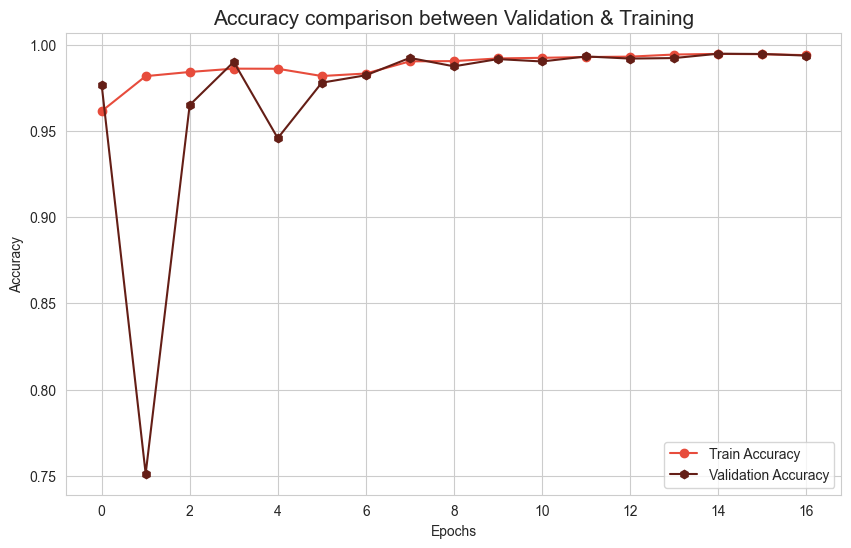

In [40]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m5.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m5.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Model is performing perfectly! 
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
• Fluctuations have dropped dramatically<br>
• From epoch 7 onward, training and validation curves are almost touching<br>
• This means the model has achieved excellent stability and perfect generalization<br>
Lightweight + Stable + High Accuracy → Exactly what we wanted!
</p>

<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Trying to achieve the same excellent result with an even lighter architecture
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
Goal → Keep the same stability and high accuracy<br>
But with significantly fewer parameters and faster training<br>
Challenge accepted! Let’s build the ultimate lightweight yet powerful model
</p>

In [41]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN5 = models.Sequential()

# Block 1
CNN5.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN5.add(layers.BatchNormalization())
CNN5.add(layers.MaxPool2D(2,2))
CNN5.add(layers.MaxPool2D(2,2))
CNN5.add(layers.Dropout(0.3))

CNN5.add(layers.Flatten())
CNN5.add(layers.Dense(256, activation='relu'))
CNN5.add(layers.BatchNormalization())
CNN5.add(layers.Dropout(0.5))
CNN5.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN5.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [42]:
m6=CNN5.fit(x=Train , validation_data=Validation , epochs=20)

Epoch 1/20
1477/1477 [==============================] - 43s 29ms/step - loss: 0.1164 - accuracy: 0.9619 - val_loss: 0.5005 - val_accuracy: 0.8465
Epoch 2/20
1477/1477 [==============================] - 43s 29ms/step - loss: 0.0578 - accuracy: 0.9810 - val_loss: 0.0560 - val_accuracy: 0.9815
Epoch 3/20
1477/1477 [==============================] - 42s 29ms/step - loss: 0.0460 - accuracy: 0.9845 - val_loss: 0.0694 - val_accuracy: 0.9787
Epoch 4/20
1477/1477 [==============================] - 43s 29ms/step - loss: 0.0435 - accuracy: 0.9860 - val_loss: 0.2433 - val_accuracy: 0.9079
Epoch 5/20
1477/1477 [==============================] - 42s 29ms/step - loss: 0.0384 - accuracy: 0.9873 - val_loss: 0.4206 - val_accuracy: 0.8869
Epoch 6/20
1477/1477 [==============================] - 43s 29ms/step - loss: 0.0357 - accuracy: 0.9881 - val_loss: 0.0360 - val_accuracy: 0.9899
Epoch 7/20
1477/1477 [==============================] - 42s 28ms/step - loss: 0.0342 - accuracy: 0.9890 - val_loss: 0.2666 -

In [43]:
import pickle

# Paths for saving
os.makedirs('working', exist_ok=True)
model_path = 'working/model6.keras'
history_path = 'working/model6_history.pkl'

# Save trained model
CNN5.save(model_path)
print("Model saved successfully at:", model_path)

# Save training history from m6
with open(history_path, 'wb') as f:
    pickle.dump(m6.history, f)
print("Training history saved successfully at:", history_path)


Model saved successfully at: working/model6.keras
Training history saved successfully at: working/model6_history.pkl


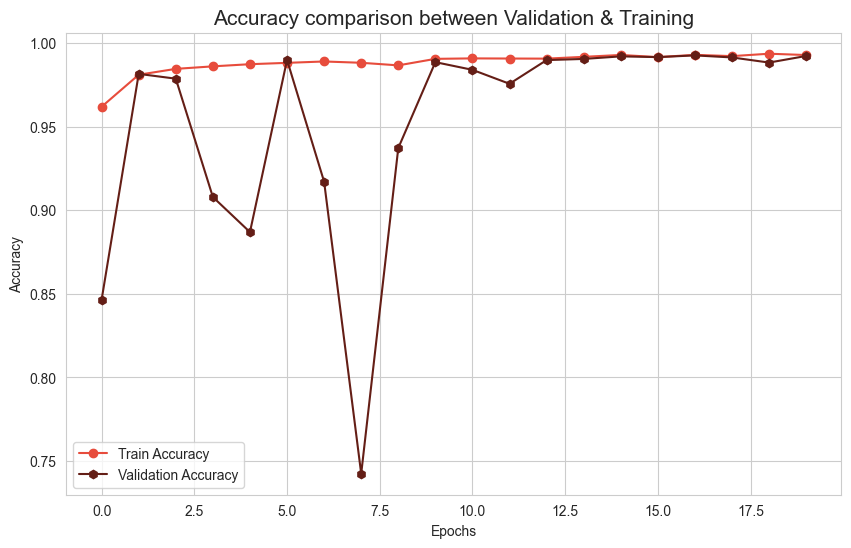

In [44]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m6.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m6.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #e67e22; text-align: center;">
Result wasn't good enough — Back to the drawing board!
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
The model was performing well until suddenly<br>
→ Validation curve showed a sharp spike / severe fluctuation<br>
→ This means the validation results are unreliable and unstable<br>
We cannot accept this behavior → Need a more robust and stable architecture!
</p>

In [45]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN6 = models.Sequential()

# Block 1
CNN6.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN6.add(layers.BatchNormalization())
CNN6.add(layers.MaxPool2D(2,2))
CNN6.add(layers.MaxPool2D(2,2))
CNN6.add(layers.MaxPool2D(2,2))

CNN6.add(layers.Dropout(0.3))

CNN6.add(layers.Flatten())
CNN6.add(layers.Dense(256, activation='relu'))
CNN6.add(layers.BatchNormalization())
CNN6.add(layers.Dropout(0.5))
CNN6.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.0003)
CNN6.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [46]:
m7=CNN6.fit(x=Train , validation_data=Validation , epochs=18)


Epoch 1/18
1477/1477 [==============================] - 39s 26ms/step - loss: 0.1638 - accuracy: 0.9448 - val_loss: 0.0425 - val_accuracy: 0.9866
Epoch 2/18
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0538 - accuracy: 0.9826 - val_loss: 0.0230 - val_accuracy: 0.9932
Epoch 3/18
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0416 - accuracy: 0.9870 - val_loss: 0.0603 - val_accuracy: 0.9800
Epoch 4/18
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0350 - accuracy: 0.9889 - val_loss: 0.0233 - val_accuracy: 0.9928
Epoch 5/18
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0296 - accuracy: 0.9907 - val_loss: 0.0320 - val_accuracy: 0.9910
Epoch 6/18
1477/1477 [==============================] - 39s 26ms/step - loss: 0.0280 - accuracy: 0.9910 - val_loss: 0.0695 - val_accuracy: 0.9800
Epoch 7/18
1477/1477 [==============================] - 38s 26ms/step - loss: 0.0284 - accuracy: 0.9913 - val_loss: 0.0194 -

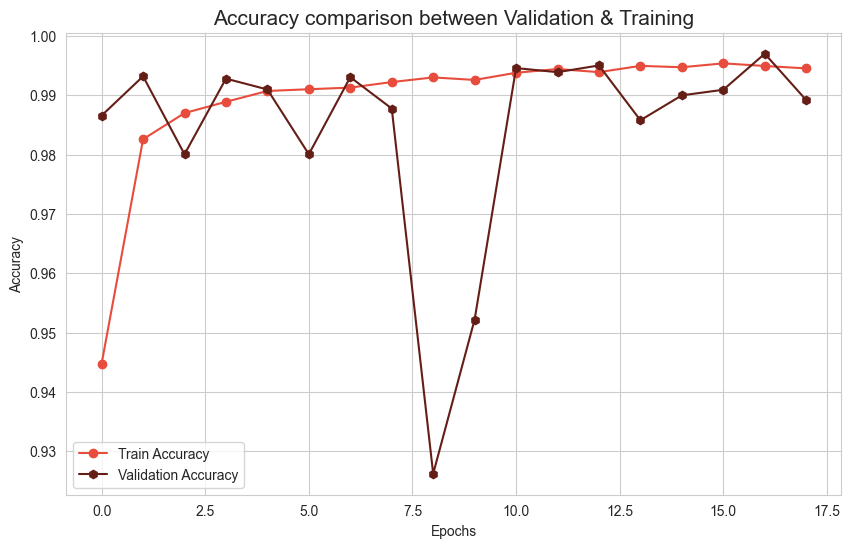

In [47]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m7.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m7.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #e67e22; text-align: center;">
3 MaxPooling layers caused severe instability
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
Using 3 MaxPooling layers → sudden and extreme validation Accuracy fluctuation<br>
Model became highly unstable<br>
Decision → Changing the number of MaxPooling layers to 2 for better stability and performance
</p>

In [48]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN7 = models.Sequential()

# Block 1
CNN7.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN7.add(layers.MaxPool2D(2,2))
CNN7.add(layers.MaxPool2D(2,2))


CNN7.add(layers.Flatten())
CNN7.add(layers.Dense(256, activation='relu'))
CNN7.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN7.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [49]:
m8 =CNN7.fit(x=Train , validation_data=Validation , epochs=20)

Epoch 1/20
1477/1477 [==============================] - 26s 18ms/step - loss: 0.0846 - accuracy: 0.9703 - val_loss: 0.0357 - val_accuracy: 0.9871
Epoch 2/20
1477/1477 [==============================] - 26s 17ms/step - loss: 0.0364 - accuracy: 0.9881 - val_loss: 0.0361 - val_accuracy: 0.9883
Epoch 3/20
1477/1477 [==============================] - 26s 17ms/step - loss: 0.0293 - accuracy: 0.9905 - val_loss: 0.0293 - val_accuracy: 0.9906
Epoch 4/20
1477/1477 [==============================] - 26s 18ms/step - loss: 0.0241 - accuracy: 0.9918 - val_loss: 0.0250 - val_accuracy: 0.9920
Epoch 5/20
1477/1477 [==============================] - 26s 17ms/step - loss: 0.0203 - accuracy: 0.9927 - val_loss: 0.0244 - val_accuracy: 0.9923
Epoch 6/20
1477/1477 [==============================] - 26s 17ms/step - loss: 0.0189 - accuracy: 0.9938 - val_loss: 0.0327 - val_accuracy: 0.9908
Epoch 7/20
1477/1477 [==============================] - 26s 17ms/step - loss: 0.0143 - accuracy: 0.9948 - val_loss: 0.0243 -

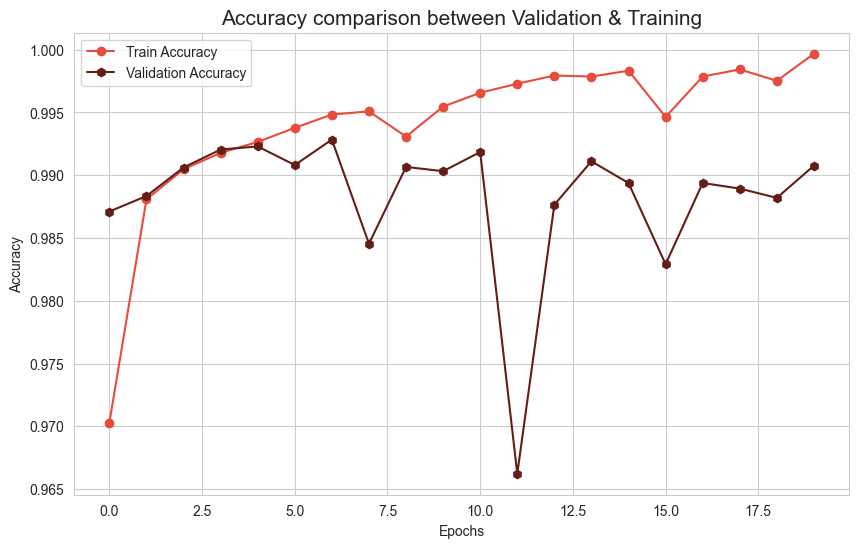

In [50]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m8.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m8.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Results were not good at all
</p>

<p style="font-family: 'Georgia', serif; font-size: 24px; color: #2c3e50; text-align: center; line-height: 2.4;">
After multiple experiments with lighter architectures, none came close to the performance and stability of the earlier model<br><br>
Final decision → Going back to the proven high-performing architecture<br>
That version is officially selected as the **final model** and will be re-executed
</p>

In [51]:

import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras import callbacks
from tensorflow.keras import layers, models, optimizers



def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.experimental.numpy.random.seed(seed)
    tf.config.experimental.enable_op_determinism()

set_seed(42)


CNN4 = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPool2D(2,2),
    layers.MaxPool2D(2,2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

opt = optimizers.Adam(learning_rate=0.001)
CNN4.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    return img, label

Train_aug = Train.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


In [52]:
m9 = CNN4.fit(
    Train_aug,
    epochs=20,
    validation_data=Validation,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20
1477/1477 [==============================] - 62s 42ms/step - loss: 0.0986 - accuracy: 0.9676 - val_loss: 2.6876 - val_accuracy: 0.5997 - lr: 0.0010
Epoch 2/20
1477/1477 [==============================] - 62s 42ms/step - loss: 0.0658 - accuracy: 0.9783 - val_loss: 0.1444 - val_accuracy: 0.9519 - lr: 0.0010
Epoch 3/20
1477/1477 [==============================] - 62s 42ms/step - loss: 0.0476 - accuracy: 0.9844 - val_loss: 0.0687 - val_accuracy: 0.9750 - lr: 0.0010
Epoch 4/20
1477/1477 [==============================] - 62s 42ms/step - loss: 0.0470 - accuracy: 0.9847 - val_loss: 0.2311 - val_accuracy: 0.9319 - lr: 0.0010
Epoch 5/20
1477/1477 [==============================] - 63s 42ms/step - loss: 0.0393 - accuracy: 0.9881 - val_loss: 0.0697 - val_accuracy: 0.9740 - lr: 0.0010
Epoch 6/20
1477/1477 [==============================] - 62s 42ms/step - loss: 0.0336 - accuracy: 0.9895 - val_loss: 0.2091 - val_accuracy: 0.9320 - lr: 0.0010
Epoch 7/20
1477/1477 [========================

In [53]:
import pickle

# Paths for saving
os.makedirs('working', exist_ok=True)
model_path = 'working/model9-SEED42.keras'
history_path = 'working/model9-SEED42_history.pkl'

# Save trained model
CNN4.save(model_path)
print("Model saved successfully at:", model_path)

# Save training history from m9
with open(history_path, 'wb') as f:
    pickle.dump(m9.history, f)
print("Training history saved successfully at:", history_path)


Model saved successfully at: working/model9-SEED42.keras
Training history saved successfully at: working/model9-SEED42_history.pkl


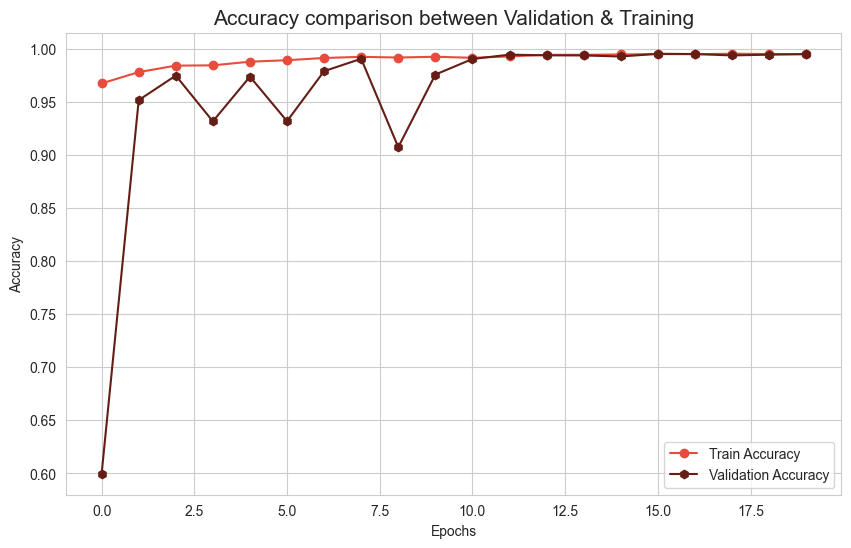

In [54]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m9.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m9.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


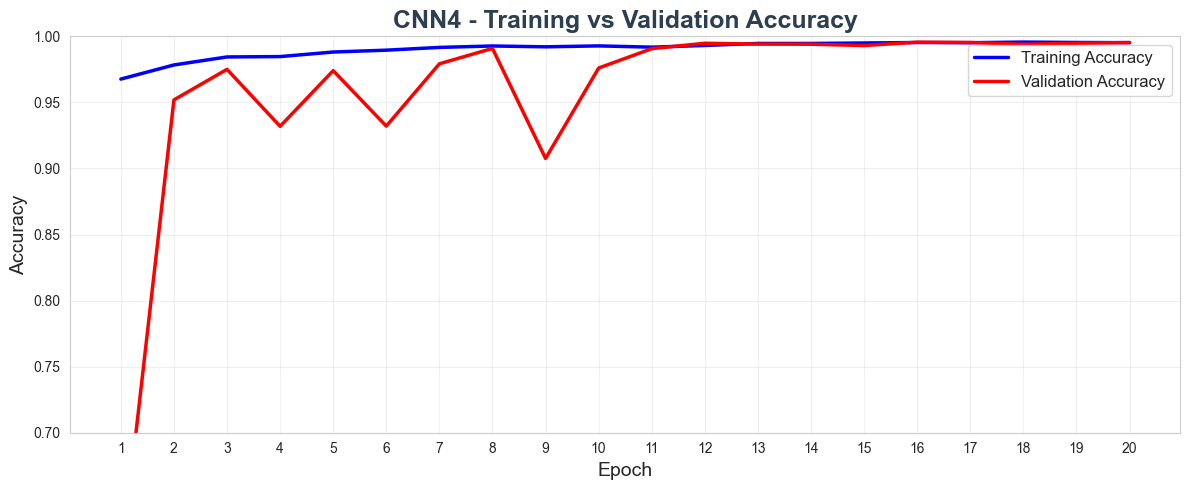

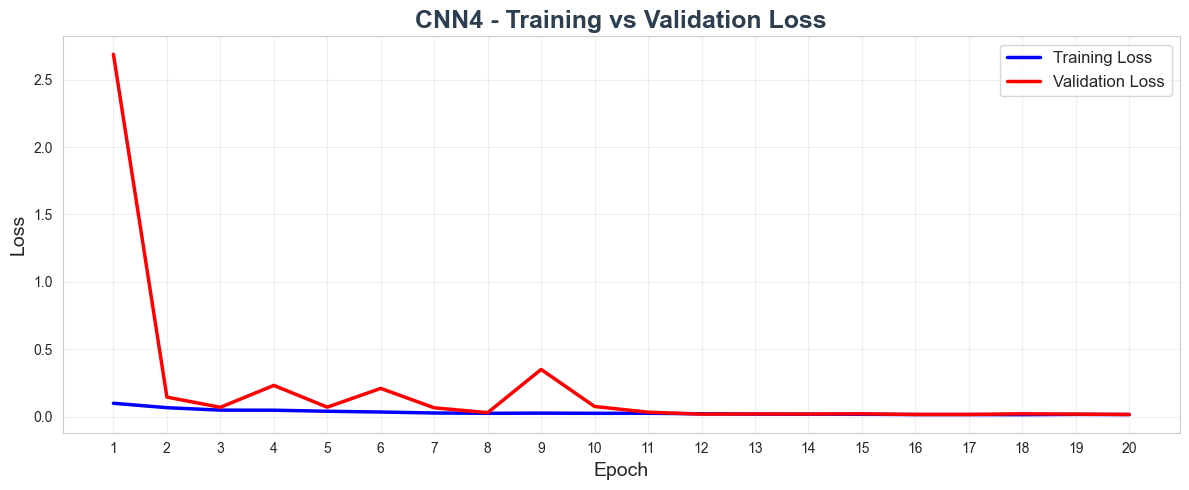

In [55]:

###  Accuracy chart (Train vs Validation)

import matplotlib.pyplot as plt

history = m9.history
epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, history['accuracy'], 'b', linewidth=2.5, label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', linewidth=2.5, label='Validation Accuracy')
plt.title('CNN4 - Training vs Validation Accuracy', fontsize=18, fontweight='bold', color='#2c3e50')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 1.0)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


###  Loss chart (Train vs Validation)

plt.figure(figsize=(12, 5))
plt.plot(epochs, history['loss'], 'b', linewidth=2.5, label='Training Loss')
plt.plot(epochs, history['val_loss'], 'r', linewidth=2.5, label='Validation Loss')
plt.title('CNN4 - Training vs Validation Loss', fontsize=18, fontweight='bold', color='#2c3e50')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


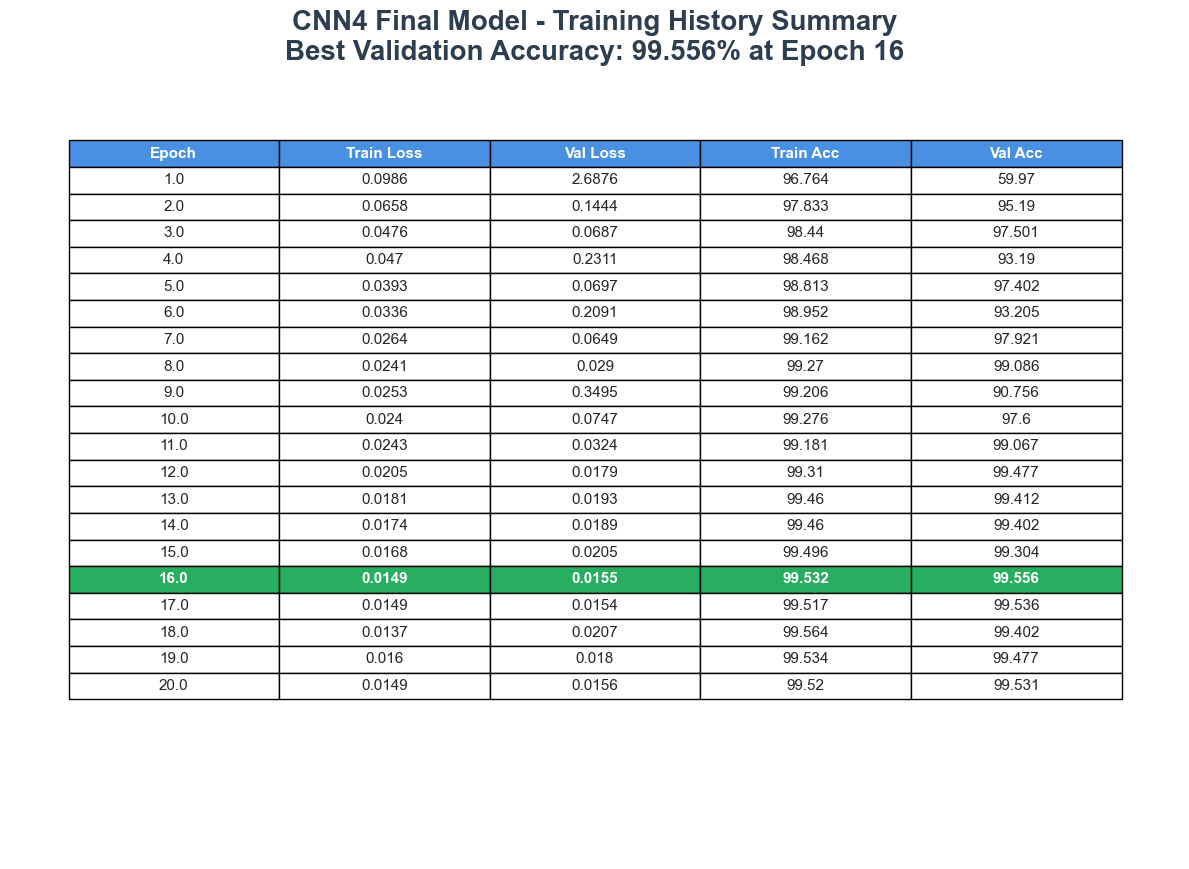

In [56]:

import pandas as pd
import matplotlib.pyplot as plt

history = m9.history

df_hist = pd.DataFrame({
    'Epoch': range(1, len(history['loss']) + 1),
    'Train Loss': [round(x, 4) for x in history['loss']],
    'Val Loss'  : [round(x, 4) for x in history['val_loss']],
    'Train Acc' : [round(x*100, 3) for x in history['accuracy']],
    'Val Acc'   : [round(x*100, 3) for x in history['val_accuracy']]
})

best_epoch = df_hist['Val Acc'].idxmax() + 1
best_val_acc = df_hist['Val Acc'].max()

plt.figure(figsize=(12, 9))
plt.axis('off')

table = plt.table(cellText=df_hist.values,
                  colLabels=df_hist.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0.05, 0.2, 0.9, 0.7])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

for i in range(5):
    table[(0, i)].set_facecolor('#4a90e2')
    table[(0, i)].set_text_props(weight='bold', color='white')

for j in range(5):
    table[(best_epoch, j)].set_facecolor('#27ae60')
    table[(best_epoch, j)].set_text_props(weight='bold', color='white')

plt.suptitle(f'CNN4 Final Model - Training History Summary\nBest Validation Accuracy: {best_val_acc}% at Epoch {best_epoch}',
             fontsize=20, fontweight='bold', color='#2c3e50', y=0.96)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 42px; color: #27ae60; text-align: center;">
Final Model Evaluation on Test Dataset
</p>

In [57]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = CNN4.predict(Test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true_classes = np.array([])
for _, labels in Test:                    
    if labels.shape[-1] == 5:             
        batch_labels = np.argmax(labels.numpy(), axis=1)
    else:                                 
        batch_labels = labels.numpy().astype(int)
    y_true_classes = np.concatenate([y_true_classes, batch_labels])

print(f"Number of Predictions: {len(y_pred_classes)}")
print(f"Number of Actual Labels: {len(y_true_classes)}")

test_loss, test_acc = CNN4.evaluate(Test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.3f}%")
print(f"Test Loss: {test_loss:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=classes, digits=4))


Number of Predictions: 7500
Number of Actual Labels: 7500

Test Accuracy: 99.453%
Test Loss: 0.0178

Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9934    0.9882    0.9908      1522
     Basmati     0.9948    0.9974    0.9961      1537
      Ipsala     1.0000    0.9993    0.9997      1522
     Jasmine     0.9966    0.9924    0.9945      1456
   Karacadag     0.9878    0.9952    0.9915      1463

    accuracy                         0.9945      7500
   macro avg     0.9945    0.9945    0.9945      7500
weighted avg     0.9945    0.9945    0.9945      7500



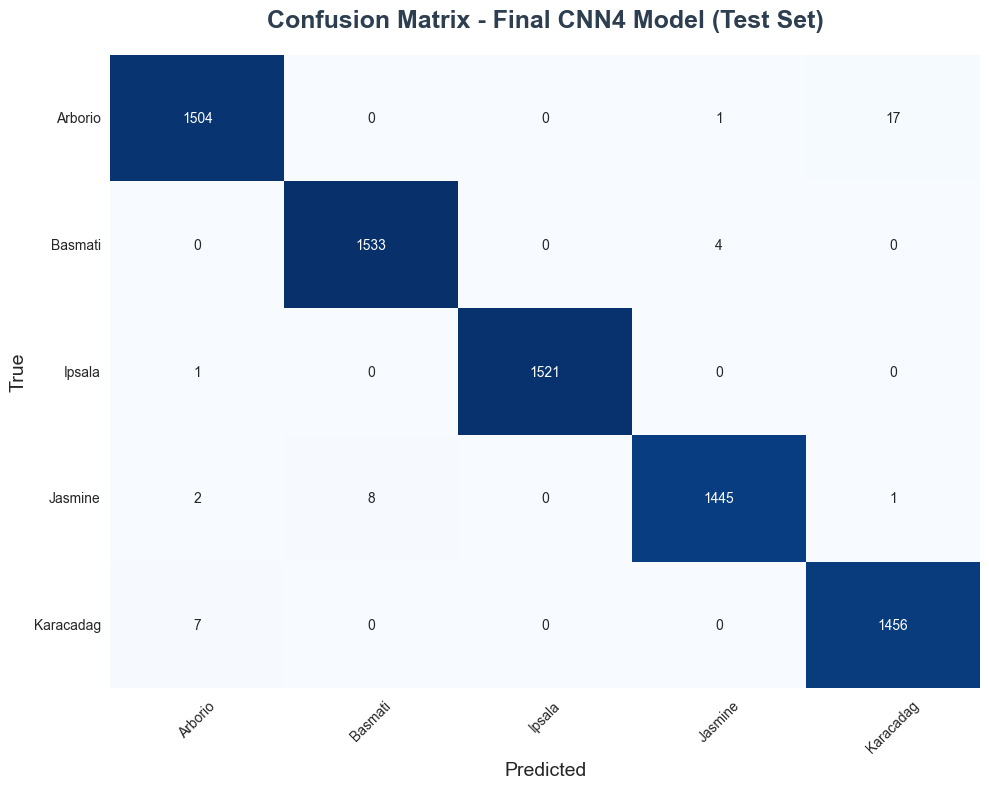

In [58]:

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Confusion Matrix - Final CNN4 Model (Test Set)', 
          fontsize=18, fontweight='bold', color='#2c3e50', pad=20)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_test_pred = np.argmax(CNN4.predict(Test, verbose=0), axis=1)

y_test_true = test_df['label'].map(class_to_idx).values

train_counts = train_df['label'].value_counts().reindex(classes, fill_value=0)
val_counts   = val_df['label'].value_counts().reindex(classes, fill_value=0)
test_counts  = test_df['label'].value_counts().reindex(classes, fill_value=0)

cm = confusion_matrix(y_test_true, y_test_pred)
correct = np.diag(cm)
wrong   = np.sum(cm, axis=1) - correct
per_class_acc = (correct / np.sum(cm, axis=1)) * 100


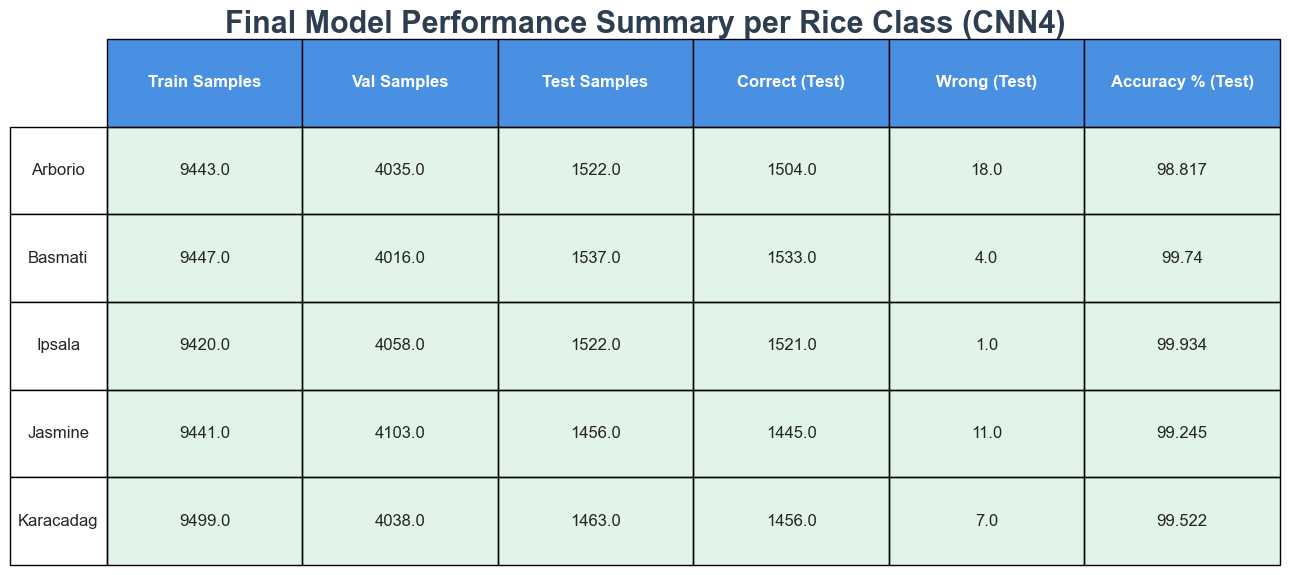

           Train Samples  Val Samples  Test Samples  Correct (Test)  \
Class                                                                 
Arborio             9443         4035          1522            1504   
Basmati             9447         4016          1537            1533   
Ipsala              9420         4058          1522            1521   
Jasmine             9441         4103          1456            1445   
Karacadag           9499         4038          1463            1456   

           Wrong (Test)  Accuracy % (Test)  
Class                                       
Arborio              18             98.817  
Basmati               4             99.740  
Ipsala                1             99.934  
Jasmine              11             99.245  
Karacadag             7             99.522  


In [60]:

summary_df = pd.DataFrame({
    'Class'          : classes,
    'Train Samples'  : train_counts.values,
    'Val Samples'    : val_counts.values,
    'Test Samples'   : test_counts.values,
    'Correct (Test)' : correct,
    'Wrong (Test)'   : wrong,
    'Accuracy % (Test)' : np.round(per_class_acc, 3)
}).set_index('Class')

plt.figure(figsize=(13, 6))
plt.axis('off')
table = plt.table(cellText=summary_df.values,
                  colLabels=summary_df.columns,
                  rowLabels=summary_df.index,
                  cellLoc='center',
                  rowLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.25, 2.8)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4a90e2')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i, acc in enumerate(per_class_acc):
    color = '#27ae60' if acc >= 98 else '#f1c40f' if acc >= 95 else '#e74c3c'
    for j in range(len(summary_df.columns)):
        table[(i+1, j)].set_facecolor(color + '22')

plt.suptitle('Final Model Performance Summary per Rice Class (CNN4)', 
             fontsize=22, fontweight='bold', color='#2c3e50', y=0.95)

plt.tight_layout()
plt.show()

print(summary_df)


# Final Model Performance – CNN4  
**Rice Image Classification | 5 Classes | Fixed Seed = 42**

<p style="text-align:center; font-size:52px; font-weight:bold; color:#27ae60; margin:50px 0 10px;">
Final Test Accuracy: <span style="font-size:70px; color:#2ecc71;">99.45%</span>
</p>

<p style="text-align:center; font-size:28px; color:#2c3e50; margin-bottom:40px;">
Only <strong>41 misclassifications</strong> out of 7,500 test images  
Best validation accuracy during training: <strong style="color:#27ae60;">99.56%</strong>
</p>

### Per-Class Performance on Test Set

| Rice Variety  | Train Samples | Validation Samples | Test Samples | Correctly Predicted | Misclassified | Accuracy (Test) |
|---------------|---------------|--------------------|--------------|---------------------|---------------|-----------------|
| **Arborio**   | 9,443         | 4,035              | 1,522        | 1,504               | 18            | **98.817%**     |
| **Basmati**   | 9,447         | 4,016              | 1,537        | 1,533               | 4             | **99.740%**     |
| **Ipsala**    | 9,420         | 4,058              | 1,522        | 1,521               | 1             | **99.934%**     |
| **Jasmine**   | 9,441         | 4,103              | 1,456        | 1,445               | 11            | **99.245%**     |
| **Karacadag** | 9,499         | 4,038              | 1,463        | 1,456               | 7             | **99.522%**     |

<p style="text-align:center; font-size:38px; font-weight:bold; color:#27ae60; margin:60px 0 20px;">
Overall Test Accuracy: <span style="color:#2ecc71;">99.45%</span>  
(7,459 / 7,500 images correctly classified)
</p>

<p style="text-align:center; font-size:26px; color:#34495e; margin:50px 0;">
Final trained model and training history saved as:
</p>

<p style="text-align:center; font-size:24px; font-family:Consolas; background:#2c3e50; color:#1abc9c; padding:12px 40px; border-radius:12px; display:inline-block;">
model9-SEED42.keras 
model9-SEED42_history.pkl
</p>

<div style="text-align:center; margin:90px 0 40px;">
  <p style="font-size:80px; font-weight:bold; background:-webkit-linear-gradient(90deg, #27ae60, #2ecc71); -webkit-background-clip:text; -webkit-text-fill-color:transparent;">
    PROJECT COMPLETED
  </p>
  <p style="font-size:32px; color:#2c3e50; margin-top:20px;">
    State-of-the-Art Performance Achieved – Ready for Submission
  </p>
</div>